# ZZ dephasing channel — noisy simulation

This notebook uses the same analytic-SVD Kraus construction as the noiseless notebook,
but now adds a first-tier NISQ-style hardware noise layer on the two-qubit
(ancilla + system) circuit and includes readout-noise-biased tomography for the
system qubit.

The plotted exact line is the ideal channel, while the obtained dots come from the
noisy simulated framework.


In [1]:
import sys
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = os.path.abspath('../..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from timeevo.ZZ.zz_dephasing import (
    analytic_svd_for_zz_kraus,
    ket_plus,
    paper_period,
    paper_time_grid,
    simulate_zz_dephasing_trajectory,
)
from noise.noise_simulation import SimpleNISQNoiseParameters
from plot.coherence_plot import plot_complex_coherence_comparison
from plot.bloch_trajectory_plot import plot_bloch_trajectory_comparison

np.set_printoptions(precision=6, suppress=True)


## 1. Tweakable physical and hardware-noise parameters

In [2]:
theta = 0.05
lambda0 = 0.7
lambda1 = 0.3

initial_state = ket_plus()
num_points = 41
periods = 1.0
times = paper_time_grid(theta=theta, periods=periods, num_points=num_points)

# Tomography shots per basis.
shots = 32000
seed = 2026

# First-tier phenomenological NISQ noise model.
# Units for T1, T2, and gate times should be consistent with each other.
noise_params = SimpleNISQNoiseParameters(
    t1_system=300.0,
    t2_system=220.0,
    t1_ancilla=260.0,
    t2_ancilla=190.0,
    one_qubit_gate_time=0.2,
    two_qubit_gate_time=1.0,
    p1q_depolarizing=0.003,
    p2q_depolarizing=0.012,
    readout_p0_to_1_system=0.012,
    readout_p1_to_0_system=0.018,
    readout_p0_to_1_ancilla=0.0,
    readout_p1_to_0_ancilla=0.0,
)

print('period =', paper_period(theta))
print('times[:5] =', times[:5])
print('shots =', shots)
print(noise_params)


period = 62.83185307179586
times[:5] = [0.       1.570796 3.141593 4.712389 6.283185]
shots = 32000
SimpleNISQNoiseParameters(t1_system=300.0, t2_system=220.0, t1_ancilla=260.0, t2_ancilla=190.0, one_qubit_gate_time=0.2, two_qubit_gate_time=1.0, p1q_depolarizing=0.003, p2q_depolarizing=0.012, readout_p0_to_1_system=0.012, readout_p1_to_0_system=0.018, readout_p0_to_1_ancilla=0.0, readout_p1_to_0_ancilla=0.0)


## 2. Inspect the analytic SVD for one selected time

In [3]:
t_selected = times[len(times)//4]
svd_k0 = analytic_svd_for_zz_kraus(t_selected, branch=0, theta=theta, lambda0=lambda0, lambda1=lambda1)
svd_k1 = analytic_svd_for_zz_kraus(t_selected, branch=1, theta=theta, lambda0=lambda0, lambda1=lambda1)

for svd in (svd_k0, svd_k1):
    print('=' * 72)
    print(svd.label, 'at t =', svd.time)
    print('reconstruction error =', np.linalg.norm(svd.reconstruct() - svd.kraus_operator))
    print('singular values =', svd.singular_values)


K0 at t = 15.707963267948966
reconstruction error = 0.0
singular values = [0.83666 0.83666]
K1 at t = 15.707963267948966
reconstruction error = 0.0
singular values = [0.547723 0.547723]


## 3. Run the noisy trajectory simulation

In [4]:
trajectory = simulate_zz_dephasing_trajectory(
    times,
    initial_state=initial_state,
    theta=theta,
    lambda0=lambda0,
    lambda1=lambda1,
    noise_params=noise_params,
    shots=shots,
    seed=seed,
    enforce_physical=True,
    renormalize_obtained_output=True,
)

print('exact shape    =', trajectory.exact_density_matrices.shape)
print('obtained shape =', trajectory.obtained_density_matrices.shape)


exact shape    = (41, 2, 2)
obtained shape = (41, 2, 2)


## 4. Inspect a few sample points

In [5]:
rows = []
for idx in [0, len(times)//4, len(times)//2, -1]:
    rho_exact = trajectory.exact_density_matrices[idx]
    rho_obt = trajectory.obtained_density_matrices[idx]
    rows.append({
        't': times[idx],
        'rho01_exact_real': np.real(rho_exact[0, 1]),
        'rho01_exact_imag': np.imag(rho_exact[0, 1]),
        'rho01_obt_real': np.real(rho_obt[0, 1]),
        'rho01_obt_imag': np.imag(rho_obt[0, 1]),
        'trace_exact': np.real(np.trace(rho_exact)),
        'trace_obt': np.real(np.trace(rho_obt)),
    })

pd.DataFrame(rows)


,t,rho01_exact_real,rho01_exact_imag,rho01_obt_real,rho01_obt_imag,trace_exact,trace_obt
0,0.000000,5.000000e-01,0.000000e+00,0.477023,-0.002660,1.0,1.0
1,15.707963,8.623817e-18,2.000000e-01,0.003891,0.184104,1.0,1.0
2,31.415927,-5.000000e-01,2.449294e-17,-0.470561,0.000522,1.0,1.0
3,62.831853,5.000000e-01,-4.898587e-17,0.477175,-0.000566,1.0,1.0


## 5. Plot the coherence: exact curve vs noisy obtained data

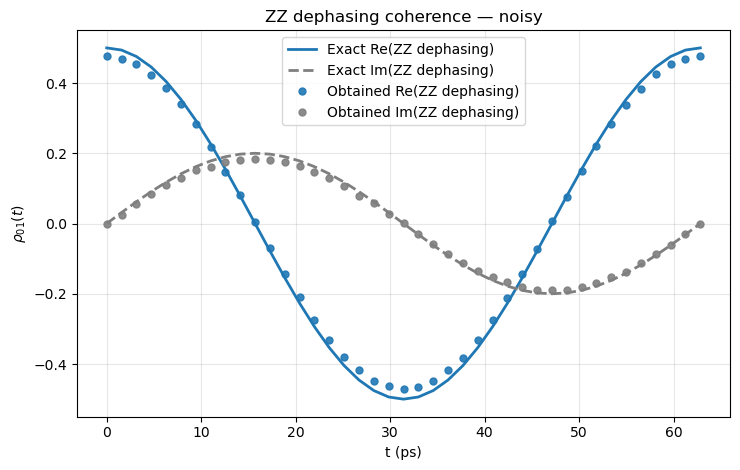

In [6]:
fig1, axs1 = plot_complex_coherence_comparison(
    trajectory.coherence_exact,
    trajectory.coherence_obtained,
    title='ZZ dephasing coherence — noisy',
    xlabel='t (ps)',
    colors = ["tab:blue", "tab:gray"],
)
plt.show()


## 6. Plot the Bloch-sphere trajectory

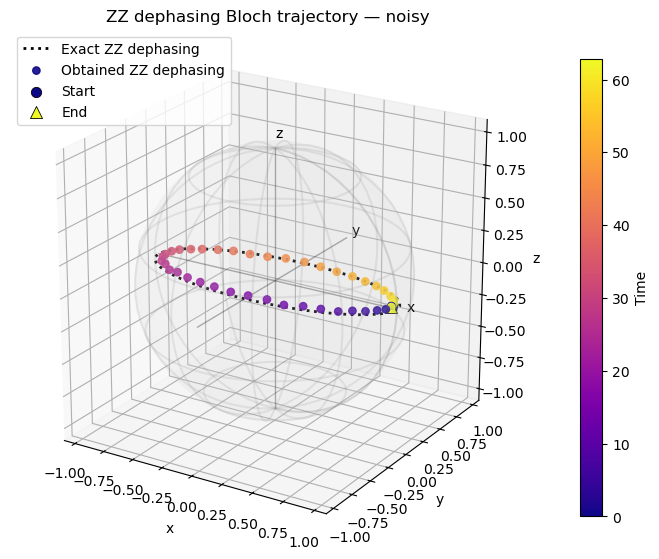

In [7]:
fig2, ax2 = plot_bloch_trajectory_comparison(
    trajectory.bloch_exact,
    trajectory.bloch_obtained,
    title='ZZ dephasing Bloch trajectory — noisy',
    cmap="plasma",
    obtained_line=False,
    show_colorbar=True,
)
plt.show()


## 7. Optional: save the figures

In [8]:
out_dir = Path.cwd()
fig1.savefig(out_dir / 'zz_noisy_coherence.png', dpi=200, bbox_inches='tight')
plt.close(fig1)
fig2.savefig(out_dir / 'zz_noisy_bloch.png', dpi=200, bbox_inches='tight')
plt.close(fig2)
